### Install Required Packages

In [15]:
!pip install xlrd


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Required Packages

In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### Load The Dataset

In [17]:
import pandas as pd

df = pd.read_excel(
    "./life_insurance_promotion.xls",
    sheet_name="Life Insurance Promotion Data"
)

### EDA

In [18]:
df.sample(n=6)

,Income Range,Life Ins Promo,Credit Card Ins.,Sex,Age
5,"20-30,000",No,No,Female,55
6,"30-40,000",Yes,Yes,Male,35
9,"30-40,000",Yes,No,Female,41
11,"20-30,000",Yes,No,Male,29
2,"40-50,000",No,No,Male,42
1,"30-40,000",Yes,No,Female,40


In [19]:
# get general info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Income Range      15 non-null     str  
 1   Life Ins Promo    15 non-null     str  
 2   Credit Card Ins.  15 non-null     str  
 3   Sex               15 non-null     str  
 4   Age               15 non-null     int64
dtypes: int64(1), str(4)
memory usage: 1013.0 bytes


In [20]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder
le = LabelEncoder()

# Convert Yes/No and Male/Female columns
cat_cols = ["Life Ins Promo", "Credit Card Ins.", "Sex"]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Convert Income Range (ordered category)
income_mapping = {
    "20-30,000": 0,
    "30-40,000": 1,
    "40-50,000": 2,
    "50-60,000": 3
}

df["Income Range"] = df["Income Range"].map(income_mapping)

# Check datatypes
print(df.dtypes)
print(df.head())

Income Range        int64
Life Ins Promo      int64
Credit Card Ins.    int64
Sex                 int64
Age                 int64
dtype: object
   Income Range  Life Ins Promo  Credit Card Ins.  Sex  Age
0             2               0                 0    1   45
1             1               1                 0    0   40
2             2               0                 0    1   42
3             1               1                 1    1   43
4             3               1                 0    0   38


In [21]:
# get statistical info
df.describe()

,Income Range,Life Ins Promo,Credit Card Ins.,Sex,Age
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,1.266667,0.600000,0.200000,0.533333,39.600000
std,1.032796,0.507093,0.414039,0.516398,9.507891
min,0.000000,0.000000,0.000000,0.000000,19.000000
25%,0.500000,0.000000,0.000000,0.000000,36.500000
50%,1.000000,1.000000,0.000000,1.000000,41.000000
75%,2.000000,1.000000,0.000000,1.000000,43.000000
max,3.000000,1.000000,1.000000,1.000000,55.000000


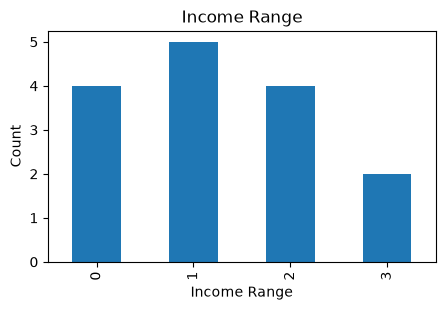

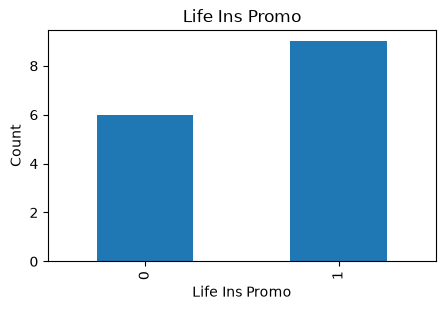

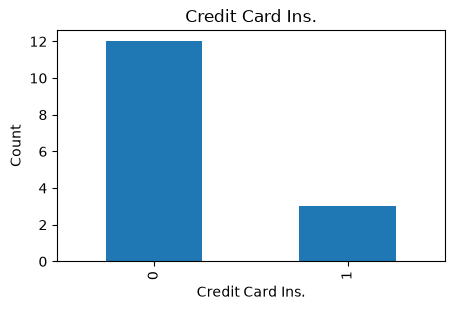

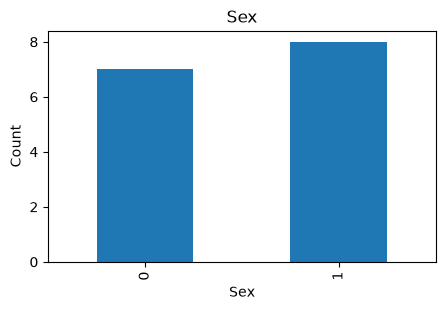

In [22]:
import matplotlib.pyplot as plt

cat_cols = ["Income Range", "Life Ins Promo", "Credit Card Ins.", "Sex"]

for col in cat_cols:
    plt.figure(figsize=(5,3))
    df[col].value_counts().sort_index().plot(kind="bar")
    plt.title(col)
    plt.ylabel("Count")
    plt.show()

In [23]:
corr = df.corr(numeric_only=True)
corr["Life Ins Promo"].abs().sort_values(ascending=False)

Life Ins Promo      1.000000
Sex                 0.490990
Age                 0.435560
Credit Card Ins.    0.408248
Income Range        0.081832
Name: Life Ins Promo, dtype: float64

### data preparation

In [24]:
# split the data into x and y 
x = df.drop(["Life Ins Promo"],axis=1)
y = df['Life Ins Promo']

In [25]:
# split the data into train and test
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42,stratify=y)

### train the models

In [26]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
model = DecisionTreeClassifier()

# Train the model
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### evaluate the model

In [27]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
#predict the train model 
y_pred = model.predict(x_train)

accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train,y_pred,average="weighted")
recall = recall_score(y_train,y_pred,average="weighted")
f1 = f1_score(y_train,y_pred,average="weighted")

print(f"accuracy = {accuracy:.2f}")
print(f"precision = {precision:.2f}")
print(f"recall = {recall:.2f}")
print(f"f1 = {f1:.2f}")

accuracy = 1.00
precision = 1.00
recall = 1.00
f1 = 1.00


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# predict the test dataset
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred,average="weighted")
recall = recall_score(y_test, y_pred,average="weighted")
f1 = f1_score(y_test, y_pred,average="weighted")

print(f"accuracy = {accuracy:.2f}")
print(f"precision = {precision:.2f}")
print(f"recall = {recall:.2f}")
print(f"f1 = {f1:.2f}")

accuracy = 0.60
precision = 0.36
recall = 0.60
f1 = 0.45


c:\Users\saurabh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
